# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 11. Мультиндексы. Примеры графиков: линейный график

В файле `Weather_Data.csv` с Kaggle сохранены данные о погоде в Австралии с 2008 по 2017 год (одна строка таблицы соответствует одному дню).

* `Date`: дата наблюдения;
* `MinTemp` и `MaxTemp`: минимальная и максимальная температура воздуха в день наблюдения;
* `Rainfall` и `Evaporation`: количество осадков и испарение (в мм);
* `Sunshine`: продолжительность солнечного сияния (в часах);
* `WindGustDir` и `WindGustSpeed`: направление и скорость сильнейшего порыва ветра;
* `WindDir9am` и `WindDir3pm`: направление ветра в 9 часа утра и в 3 часа дня;
* `WindSpeed9am` и `WindSpeed3pm`: скорость ветра в 9 часа утра и в 3 часа дня;
* `Humidity9am` и `Humidity3pm`: влажность в 9 часа утра и в 3 часа дня;
* `Pressure9am` и `Pressure3pm`: атмосферное давление в 9 часа утра и в 3 часа дня;
* `Cloud9am` и `Cloud3pm`: облачность в 9 часа утра и в 3 часа дня;
* `Temp9am` и `Temp3pm`: температура воздуха в 9 часа утра и в 3 часа дня;
* `RainToday`: шёл ли дождь в день наблюдения;
* `RainTomorrow`: шёл ли дождь в день, следующий за днём наблюдения.

Загрузите данные из файла `Weather_Data.csv` и сохраните их в датафрейм `df`.

In [1]:
import pandas as pd

df = pd.read_csv("Weather_Data.csv")

### Задача 1

Добавьте столбец `Year` с годом наблюдения и столбец `Month` с месяцем наблюдения.

In [2]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year
df["Month"] = pd.to_datetime(df["Date"]).dt.month

### Задача 2

Сгруппируйте данные по году и месяцу и вычислите среднюю температуру в 3 часа дня. Сохраните результат в переменную `avg`. Примените метод `.plot()` и постройте линейный график, показывающий динамику средней температуры воздуха по месяцам в изучаемый период.

In [3]:
avg = df.groupby(["Year", "Month"])["Temp3pm"].mean()
avg

Year  Month
2008  2        23.203448
      3        24.077419
      4        20.365517
      5        19.461290
      6        17.820000
                 ...    
2017  2        26.953571
      3        24.067742
      4        22.148276
      5        20.245161
      6        17.620000
Name: Temp3pm, Length: 110, dtype: float64

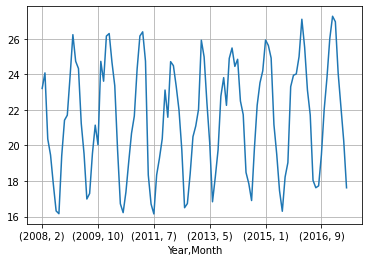

In [4]:
# пары год-месяц являются индексами,
# средние значения температуры – значениями,
# поэтому по оси X отмечаются пары, 
# а по оси Y – температура

# grid = True – добавляем сетку

avg.plot(grid = True);

### Задача 3

Посмотрите на тип и индексы элементов объекта `avg`. Выберите: 

* среднюю температуру по всем месяцам в 2016 году;
* среднюю температуру в январе по всем годам.

Постройте графики для динамики температуры для каждого пункта.

In [5]:
# тип avg – последовательность pandas Series,
# это один столбец с мультиндексами, они 
# двухуровневые, первый уровень – год, второй – месяц

print(type(avg))
print(avg.index)

<class 'pandas.core.series.Series'>
MultiIndex([(2008,  2),
            (2008,  3),
            (2008,  4),
            (2008,  5),
            (2008,  6),
            (2008,  7),
            (2008,  8),
            (2008,  9),
            (2008, 10),
            (2008, 11),
            ...
            (2016,  9),
            (2016, 10),
            (2016, 11),
            (2016, 12),
            (2017,  1),
            (2017,  2),
            (2017,  3),
            (2017,  4),
            (2017,  5),
            (2017,  6)],
           names=['Year', 'Month'], length=110)


In [6]:
# средняя температура по всем месяцам в 2016 году
# два варианта получения

print(avg[2016])
print(avg.xs(2016, level = "Year")) # или level = 0

Month
1     24.993333
2     27.093103
3     25.509677
4     23.113333
5     21.709677
6     18.037931
7     17.623333
8     17.730000
9     19.466667
10    22.032258
11    23.817241
12    25.996774
Name: Temp3pm, dtype: float64
Month
1     24.993333
2     27.093103
3     25.509677
4     23.113333
5     21.709677
6     18.037931
7     17.623333
8     17.730000
9     19.466667
10    22.032258
11    23.817241
12    25.996774
Name: Temp3pm, dtype: float64


In [7]:
# средняя температура в январе по всем годам
# два варианта получения

print(avg[:, 1]) # все годы, месяц 1
print(avg.xs(1, level = "Month")) # или level = 1

Year
2009    26.225806
2010    26.148387
2011    26.151613
2012    24.710000
2013    25.912903
2014    25.477419
2015    25.925806
2016    24.993333
2017    27.261290
Name: Temp3pm, dtype: float64
Year
2009    26.225806
2010    26.148387
2011    26.151613
2012    24.710000
2013    25.912903
2014    25.477419
2015    25.925806
2016    24.993333
2017    27.261290
Name: Temp3pm, dtype: float64


### Задача 4

* Примените к `avg` метод `.reset_index()`. Что получилось? Сохраните результат как `df_avg`. 
* Примените к `avg` метод `.unstack()`. Что получилось? Сохраните результат как `avg_wide`. Что будет, если применить метод  `.unstack()` еще раз?

In [8]:
# индексы перешли в столбцы,
# вместо одного столбца pandas Series
# получился датафрейм pandas DataFrame с тремя столбцами,
# индексы строк – обычные целые числа

df_avg = avg.reset_index()
df_avg

,Year,Month,Temp3pm
0,2008,2,23.203448
1,2008,3,24.077419
2,2008,4,20.365517
3,2008,5,19.461290
4,2008,6,17.820000
...,...,...,...
105,2017,2,26.953571
106,2017,3,24.067742
107,2017,4,22.148276
108,2017,5,20.245161


In [9]:
# от длинного формата (long format), 
# где все группы записаны в один столбец,
# перешли к широкому формату (wide format),
# где группы (месяцы) записаны в отдельные столбцы

avg_wide = avg.unstack()
avg_wide

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2008,NaN,23.203448,24.077419,20.365517,19.461290,17.820000,16.319355,16.163333,19.420000,21.419355,21.700000,23.893548
2009,26.225806,24.728571,24.322581,21.231034,19.525806,16.990000,17.300000,19.541935,21.140000,20.034483,24.726667,23.610714
2010,26.148387,26.289286,24.670968,23.358621,19.767742,16.722222,16.223333,17.386667,19.084000,20.683333,21.652000,24.286207
2011,26.151613,26.385714,24.735484,NaN,18.341935,16.706667,16.151613,18.341935,19.280000,20.374194,23.114286,21.583871
2012,24.710000,24.482759,23.329032,21.993103,19.774194,16.500000,16.733333,18.400000,20.488889,21.090000,22.030000,NaN
2013,25.912903,NaN,24.974194,22.396667,20.145161,16.833333,18.222581,19.754839,22.773333,23.809677,22.253333,24.893548
2014,25.477419,24.442857,24.841935,22.496667,21.732258,18.483333,17.854839,16.903226,19.814286,22.263333,23.519231,24.193333
2015,25.925806,25.621429,24.909677,21.170000,19.506452,17.463333,16.300000,18.225806,19.036667,23.303226,23.944828,24.017241
2016,24.993333,27.093103,25.509677,23.113333,21.709677,18.037931,17.623333,17.730000,19.466667,22.032258,23.817241,25.996774


In [10]:
# если применить метод дважды, 
# из широкого формата мы снова получим длинный,
# однако результат отличается от исходного avg;
# так как из-за отсутствия данных в широкой таблице
# добавились NaN, в длинном столбце они тоже остались

avg.unstack().unstack()

Month  Year
1      2008          NaN
       2009    26.225806
       2010    26.148387
       2011    26.151613
       2012    24.710000
                 ...    
12     2013    24.893548
       2014    24.193333
       2015    24.017241
       2016    25.996774
       2017          NaN
Length: 120, dtype: float64

### Задача 5

Используя данные в `df_avg`, постройте линейные графики для отражения динамики среднемесячной температуры воздуха в период с 2008 по 2016 год. Должно получиться 12 графиков в одних осях, каждый из которых показывает изменение средней температуры в выбранный месяц в течение 8 лет.

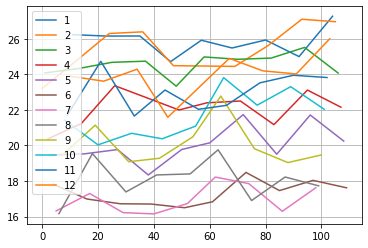

In [11]:
# добавляем легенду legend = True

df_avg.groupby("Month")['Temp3pm'].plot(grid = True, legend = True);

> **Важно.** Это плохой график! Во-первых, 12 линий на одном графике – много, сравнивать динамику температуры по месяцам неудобно. Во-вторых, максимальное число уникальных цветов 10, а месяцев 12, в итоге январь и ноябрь одинакового синего цвета, а февраль и декабрь одинакового оранжевого цвета. Лучше разбить все на отдельные графики (как в задаче ниже) или сделать разбивку по сезонам.

### Задача 6

Используя данные в `df_wide`, постройте линейные графики для отражения динамики среднемесячной температуры воздуха в период с 2008 по 2016 год. Должно получиться 12 графиков в разных осях, каждый из которых показывает изменение средней температуры в выбранный месяц в течение 8 лет.

Какую проблему вы наблюдаете? Как ее исправить?

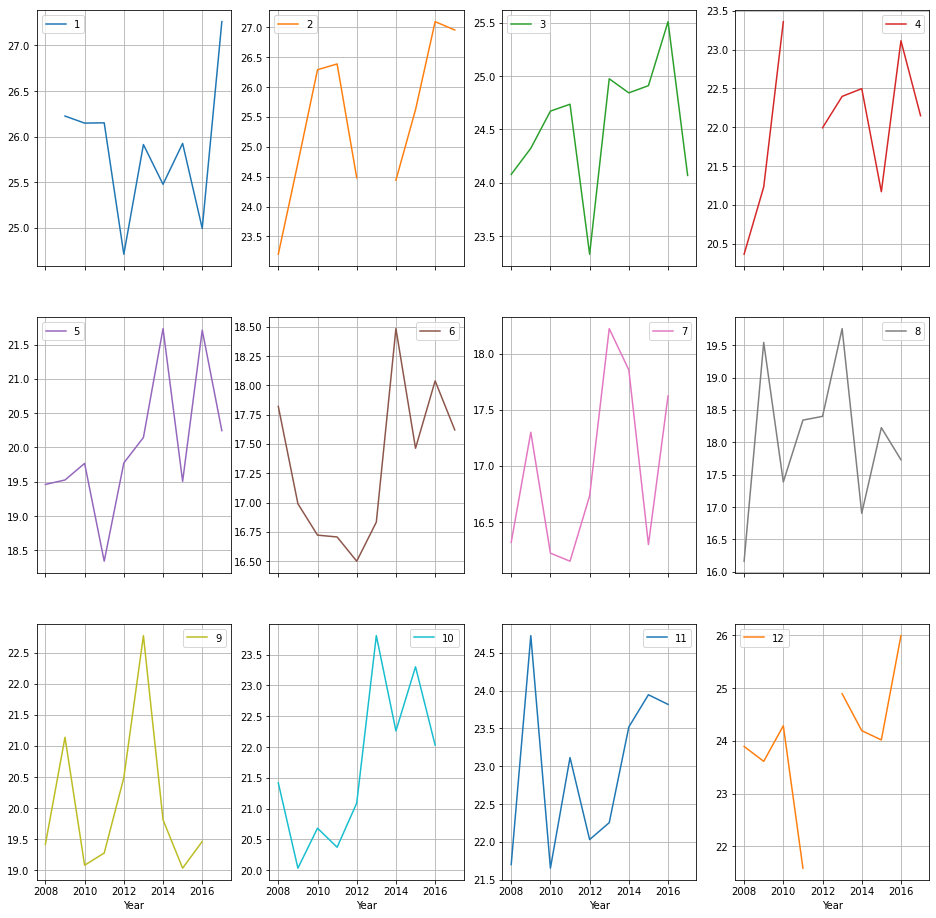

In [12]:
# опечатка – имеется в виду avg_wide
# добавляем подграфики subplots, чтобы 
# разные месяцы были в отдельных осях,
# layout – размерность сетки с графиками, 
# 12 графиков распределяем на 3 строки и 4 столбца

avg_wide.plot(subplots = True,
              grid = True,
              figsize = (16, 16),
              layout = (3, 4));

Проблема: на некоторых графиках есть разрывы. Они возникают из-за пропущенных значений (в `avg_wide` мы видели `NaN`).

In [13]:
avg_wide

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2008,NaN,23.203448,24.077419,20.365517,19.461290,17.820000,16.319355,16.163333,19.420000,21.419355,21.700000,23.893548
2009,26.225806,24.728571,24.322581,21.231034,19.525806,16.990000,17.300000,19.541935,21.140000,20.034483,24.726667,23.610714
2010,26.148387,26.289286,24.670968,23.358621,19.767742,16.722222,16.223333,17.386667,19.084000,20.683333,21.652000,24.286207
2011,26.151613,26.385714,24.735484,NaN,18.341935,16.706667,16.151613,18.341935,19.280000,20.374194,23.114286,21.583871
2012,24.710000,24.482759,23.329032,21.993103,19.774194,16.500000,16.733333,18.400000,20.488889,21.090000,22.030000,NaN
2013,25.912903,NaN,24.974194,22.396667,20.145161,16.833333,18.222581,19.754839,22.773333,23.809677,22.253333,24.893548
2014,25.477419,24.442857,24.841935,22.496667,21.732258,18.483333,17.854839,16.903226,19.814286,22.263333,23.519231,24.193333
2015,25.925806,25.621429,24.909677,21.170000,19.506452,17.463333,16.300000,18.225806,19.036667,23.303226,23.944828,24.017241
2016,24.993333,27.093103,25.509677,23.113333,21.709677,18.037931,17.623333,17.730000,19.466667,22.032258,23.817241,25.996774


Чтобы исправить проблему, нужно заполнить пропуски. Во временных данных, если нет необходимости в усреднении значений за определенный период, на место отсутствующего значения просто «перетягивают» число за прошлый год или месяц. В методе `.fillna()` такой способ заполнения пропусков называется `ffill` (от *forward fill*, заполнение вперед):

In [14]:
avg_wide.fillna(method = "ffill")

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2008,NaN,23.203448,24.077419,20.365517,19.461290,17.820000,16.319355,16.163333,19.420000,21.419355,21.700000,23.893548
2009,26.225806,24.728571,24.322581,21.231034,19.525806,16.990000,17.300000,19.541935,21.140000,20.034483,24.726667,23.610714
2010,26.148387,26.289286,24.670968,23.358621,19.767742,16.722222,16.223333,17.386667,19.084000,20.683333,21.652000,24.286207
2011,26.151613,26.385714,24.735484,23.358621,18.341935,16.706667,16.151613,18.341935,19.280000,20.374194,23.114286,21.583871
2012,24.710000,24.482759,23.329032,21.993103,19.774194,16.500000,16.733333,18.400000,20.488889,21.090000,22.030000,21.583871
2013,25.912903,24.482759,24.974194,22.396667,20.145161,16.833333,18.222581,19.754839,22.773333,23.809677,22.253333,24.893548
2014,25.477419,24.442857,24.841935,22.496667,21.732258,18.483333,17.854839,16.903226,19.814286,22.263333,23.519231,24.193333
2015,25.925806,25.621429,24.909677,21.170000,19.506452,17.463333,16.300000,18.225806,19.036667,23.303226,23.944828,24.017241
2016,24.993333,27.093103,25.509677,23.113333,21.709677,18.037931,17.623333,17.730000,19.466667,22.032258,23.817241,25.996774


Почти все пропуски заполнены, например, температура в феврале 2013 года скопировалась из 2012 года, температура в апреле 2011 – из 2010. Однако один пропуск все еще остался – данные за январь 2008 года брать неоткуда, 2008 год в таблице самый ранний. Выход один – скопировать значение за следующий год, воспользовавшись способом заполнения `bfill` (от *backward fill*):

In [15]:
avg_wide = avg_wide.fillna(method = "ffill").fillna(method = "bfill")
avg_wide

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2008,26.225806,23.203448,24.077419,20.365517,19.461290,17.820000,16.319355,16.163333,19.420000,21.419355,21.700000,23.893548
2009,26.225806,24.728571,24.322581,21.231034,19.525806,16.990000,17.300000,19.541935,21.140000,20.034483,24.726667,23.610714
2010,26.148387,26.289286,24.670968,23.358621,19.767742,16.722222,16.223333,17.386667,19.084000,20.683333,21.652000,24.286207
2011,26.151613,26.385714,24.735484,23.358621,18.341935,16.706667,16.151613,18.341935,19.280000,20.374194,23.114286,21.583871
2012,24.710000,24.482759,23.329032,21.993103,19.774194,16.500000,16.733333,18.400000,20.488889,21.090000,22.030000,21.583871
2013,25.912903,24.482759,24.974194,22.396667,20.145161,16.833333,18.222581,19.754839,22.773333,23.809677,22.253333,24.893548
2014,25.477419,24.442857,24.841935,22.496667,21.732258,18.483333,17.854839,16.903226,19.814286,22.263333,23.519231,24.193333
2015,25.925806,25.621429,24.909677,21.170000,19.506452,17.463333,16.300000,18.225806,19.036667,23.303226,23.944828,24.017241
2016,24.993333,27.093103,25.509677,23.113333,21.709677,18.037931,17.623333,17.730000,19.466667,22.032258,23.817241,25.996774


Строим графики еще раз – разрывов нет:

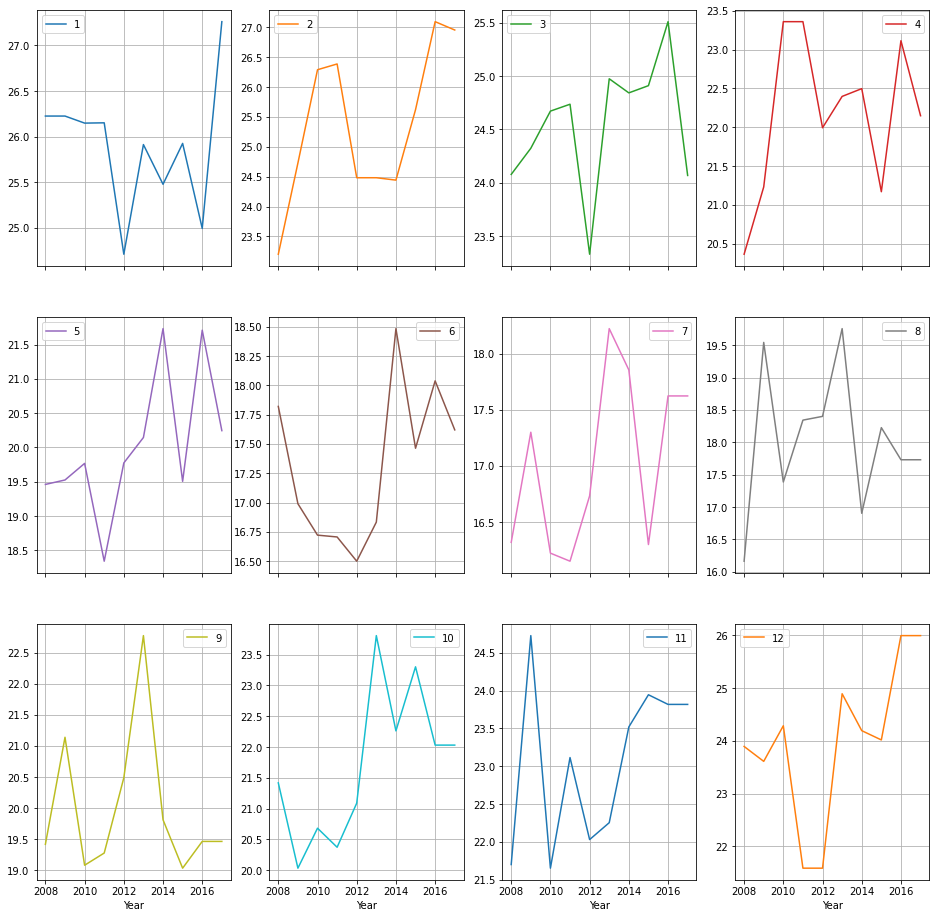

In [16]:
avg_wide.plot(subplots = True,
              grid = True,
              figsize = (16, 16),
              layout = (3, 4));